In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import math
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import colors
from matplotlib import gridspec
from matplotlib.colors import Normalize, TwoSlopeNorm
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import seaborn as sns

In [2]:
ds = xr.open_dataset("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/bootstrap_summary.nc",
                    engine='h5netcdf')
# Generator site list
gen_csv = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")

In [3]:
# Statistically significant w ssmin=20, and Mann-Whitney 
cluster = ['TARALGA1','CROOKWF2',
            'GULLRWF1',
            'GUNNING1',
            'CRURWF1',
            'WOODLWN1',
            'BOCORWF1',
            'BODWF1']

cluster = gen_csv[gen_csv['DUID'].isin(cluster)][['DUID','lat','lon']]

In [4]:
output_dir = '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/bootstrap'

In [5]:
lon = ds.coords['lon'].values
lat = ds.coords['lat'].values

extent = [ds.coords['lon'].min().item(),
          ds.coords['lon'].max().item(),
          ds.coords['lat'].min().item(),
          ds.coords['lat'].max().item()]
lon_min, lon_max, lat_min, lat_max = extent

In [6]:
ds

<xarray.Dataset> Size: 100MB
Dimensions:                 (hour: 24, lon: 125, lat: 163)
Coordinates:
  * hour                    (hour) int32 96B 0 1 2 3 4 5 6 ... 18 19 20 21 22 23
    height                  float64 8B ...
  * lon                     (lon) float64 1kB 147.0 147.1 147.1 ... 151.9 152.0
  * lat                     (lat) float64 1kB -38.49 -38.45 ... -32.05 -32.01
    crs                     int32 4B ...
Data variables: (12/54)
    hw_u_mean               (lat, lon, hour) float32 2MB ...
    hw_u_std                (lat, lon, hour) float32 2MB ...
    hw_u_ci_low             (lat, lon, hour) float32 2MB ...
    hw_u_ci_high            (lat, lon, hour) float32 2MB ...
    hw_v_mean               (lat, lon, hour) float32 2MB ...
    hw_v_std                (lat, lon, hour) float32 2MB ...
    ...                      ...
    diff_sig_magnitude_005  (lat, lon, hour) bool 489kB ...
    diff_sig_magnitude_001  (lat, lon, hour) bool 489kB ...
    diff_sig_joint_005      (lat, lon, hour) bool 489kB ...
    diff_sig_joint_001      (lat, lon, hour) bool 489kB ...
    diff_u_pval             (lat, lon, hour) float32 2MB ...
    diff_v_pval             (lat, lon, hour) float32 2MB ...

In [7]:
def calc_divergence(u, v, lat, lon):
    R = 6371000  # Earth radius in meters
    
    lat_rad = np.deg2rad(lat)
    dx_1d = np.gradient(lon) * (np.pi/180) * R
    dx2d = dx_1d[None, :] * np.cos(lat_rad[:, None])
    
    dy2d = np.gradient(lat) * (np.pi/180) * R
    dy2d = dy2d[:, None]
    
    dudx = np.gradient(u, axis=-1) / dx2d
    dvdy = np.gradient(v, axis=-2) / dy2d
    return dudx + dvdy


In [8]:
hw_div = xr.apply_ufunc(
    calc_divergence,
    ds['hw_u_mean'], ds['hw_v_mean'],
    ds['lat'], ds['lon'],
    input_core_dims=[['lat', 'lon'], ['lat', 'lon'], ['lat'], ['lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True,  # loop over hour
    dask='parallelized',  # if using dask
    output_dtypes=[ds['hw_u_mean'].dtype]
)

bl_div = xr.apply_ufunc(
    calc_divergence,
    ds['bl_u_mean'], ds['bl_v_mean'],
    ds['lat'], ds['lon'],
    input_core_dims=[['lat', 'lon'], ['lat', 'lon'], ['lat'], ['lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True,  # loop over hour
    dask='parallelized',  # if using dask
    output_dtypes=[ds['bl_u_mean'].dtype]
)
div_max = max(hw_div.max(),bl_div.max())
div_min = max(hw_div.min(),bl_div.min())

In [9]:
hw_max = ds['hw_speed_mean'].max()
hw_min = ds['hw_speed_mean'].min()

bl_max = ds['bl_speed_mean'].max()
bl_min = ds['bl_speed_mean'].min()

In [10]:
def facet_plot_hours(
        lon, lat, scalar, u=None, v=None, stipple=None,
        hours=None, ncols=4, figsize=(14, 8),
        cmap='viridis', norm=None,
        vmin=None, vmax=None,
        center_diff=False, center_value=0.0, symmetric_if_center=True,
        vector_scale=50, vector_subsample=(6, 6),
        stipple_size=100, stipple_color='k',
        title_prefix='',
        quiver_color='white', quiver_width=0.003,
        share_colorbar=True, colorbar_label='',
        add_borders=True, add_states=True,
        title=None, cluster=cluster, highlight_id='BOCORWF1'
        ):
    """
    Faceted plot by hour using Matplotlib + Cartopy, with state and coastal borders.

    Parameters
    ----------
    lon, lat : 1D arrays
        Longitude and latitude coordinates.
    scalar : ndarray
        3D array with dimensions containing (hour, lat, lon) in some order. Will be
        auto-permuted to (hour, lat, lon).
    u, v : ndarray, optional
        3D wind component arrays on same grid/order as scalar. Will be permuted similarly.
    stipple : ndarray(bool or float), optional
        3D array. If float, values < 0.05 (default logic) are treated as True for stippling.
    hours : list[int], optional
        Subset of hour indices to plot.
    vmin, vmax : float, optional
        Explicit color scale limits (ignored if norm is provided).
    norm : matplotlib.colors.Normalize or subclass, optional
        If provided, used directly. Overrides vmin/vmax logic.
    center_diff : bool
        If True, use a TwoSlopeNorm centered at center_value.
        Priority order:
          1. If norm is provided: use it
          2. Else if center_diff True:
               a. If vmin/vmax given and symmetric_if_center True -> expand to symmetric about center_value
               b. Else if vmin/vmax given -> honor them literally
               c. Else auto-compute symmetric bounds from data
    center_value : float
        Center for TwoSlopeNorm if center_diff is True.
    symmetric_if_center : bool
        Whether to force symmetry around center_value when center_diff=True and user supplies vmin/vmax.
    share_colorbar : bool
        Draw a colorbar in an extra column.
    return_norm : bool
        If True, include the norm used in the return tuple.
    return_mappable : bool
        If True, include the last pcolormesh (for external colorbar creation).

    Returns
    -------
    fig : Figure
    axes_flat : list[Axes]
    (optional) norm_used
    (optional) last_mappable

    Notes
    -----
    To ensure multiple calls share identical scaling, build a Normalize (or TwoSlopeNorm)
    externally and pass via norm. Example:

        shared_norm = Normalize(vmin=-5, vmax=15)
        fig1, ax1 = facet_plot_hours(..., norm=shared_norm, share_colorbar=False)
        fig2, ax2 = facet_plot_hours(..., norm=shared_norm, share_colorbar=False)
        # Then create a single colorbar:
        import matplotlib.pyplot as plt
        cbar = plt.colorbar(plt.cm.ScalarMappable(norm=shared_norm, cmap='viridis'),
                            ax=ax1 + ax2, orientation='horizontal')
    """
    # --- Ensure numpy arrays ---
    scalar = np.asarray(scalar)
    if u is not None: u = np.asarray(u)
    if v is not None: v = np.asarray(v)
    if stipple is not None: stipple = np.asarray(stipple)

    if scalar.ndim != 3:
        raise ValueError(f"Expect 3D scalar array, got shape {scalar.shape}")

    nh_guess, nlat_guess, nlon_guess = scalar.shape
    # --- Auto-reorder scalar to (hour, lat, lon) ---
    found = False
    for perm in permutations(range(3)):
        test = scalar.transpose(perm)
        if test.shape[1] == len(lat) and test.shape[2] == len(lon):
            scalar = test
            if u is not None: u = u.transpose(perm)
            if v is not None: v = v.transpose(perm)
            if stipple is not None: stipple = stipple.transpose(perm)
            found = True
            break
    if not found:
        raise ValueError(f"Cannot reconcile scalar shape {scalar.shape} with lat={len(lat)}, lon={len(lon)}")

    nh = scalar.shape[0]

    # --- Select hours ---
    if hours is None:
        sel_indices = list(range(nh))
        print(sel_indices)

    else:
        hour_coord = np.arange(nh)
        sel_indices = []
        for h in hours:
            if h in hour_coord:
                sel_indices.append(int(np.where(hour_coord == h)[0][0]))
            elif 0 <= h < nh:
                sel_indices.append(int(h))
            else:
                raise ValueError(f"Hour {h} not found")
    nplots = len(sel_indices)
    ncols = max(1, ncols)
    nrows = math.ceil(nplots / ncols)

    # --- Figure & GridSpec (reserve last col for colorbar if share_colorbar) ---
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, ncols + (1 if share_colorbar else 0),
                           figure=fig,
                           wspace=0.02, hspace=0.08,
                           width_ratios=[1]*ncols + ([0.2] if share_colorbar else []))
    axes_flat = []

    # --- Determine normalization ---
    panel_data = scalar[sel_indices]

    if norm is not None:
        norm_used = norm
    else:
        if center_diff:
            # Determine bounds
            if vmin is not None or vmax is not None:
                # If only one is provided, try to infer counterpart from data
                data_min = np.nanmin(panel_data)
                data_max = np.nanmax(panel_data)
                vmin_eff = vmin if vmin is not None else data_min
                vmax_eff = vmax if vmax is not None else data_max
                if symmetric_if_center:
                    # Make symmetric about center_value
                    dist_min = center_value - vmin_eff
                    dist_max = vmax_eff - center_value
                    bound = max(dist_min, dist_max)
                    vmin_eff = center_value - bound
                    vmax_eff = center_value + bound
                norm_used = TwoSlopeNorm(vcenter=center_value, vmin=vmin_eff, vmax=vmax_eff)
            else:
                dmin = np.nanmin(panel_data)
                dmax = np.nanmax(panel_data)
                # Symmetric about center_value
                dist_min = center_value - dmin
                dist_max = dmax - center_value
                bound = max(dist_min, dist_max)
                norm_used = TwoSlopeNorm(vcenter=center_value,
                                         vmin=center_value - bound,
                                         vmax=center_value + bound)
        else:
            # Simple Normalize
            if vmin is None: vmin = np.nanmin(panel_data)
            if vmax is None: vmax = np.nanmax(panel_data)
            norm_used = Normalize(vmin=vmin, vmax=vmax)

    # --- Vector subsampling prep ---
    if u is not None and v is not None:
        si, sj = vector_subsample
        lat_vec = lat[::si]
        lon_vec = lon[::sj]
        Lon2d_vec, Lat2d_vec = np.meshgrid(lon_vec, lat_vec)

    # --- Full meshgrid for stipple ---
    Lon2d, Lat2d = np.meshgrid(lon, lat)

    last_mappable = None

    # --- Plot each panel ---
    for i, idx in enumerate(sel_indices):
        row = i // ncols
        col = i % ncols
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        axes_flat.append(ax)

        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=0)
        if add_borders:
            ax.add_feature(cfeature.BORDERS.with_scale('50m'), edgecolor='black', linewidth=0.5, zorder=5)
        if add_states:
            ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5, zorder=6)

        panel = scalar[idx]
        pm = ax.pcolormesh(lon, lat, panel, cmap=cmap, norm=norm_used,
                           shading='auto', transform=ccrs.PlateCarree(), zorder=1)
        last_mappable = pm  # keep reference

        if u is not None and v is not None:
            si, sj = vector_subsample
            u_i = u[idx][::si, ::sj]
            v_i = v[idx][::si, ::sj]
            ax.quiver(Lon2d_vec, Lat2d_vec, u_i, v_i, angles='xy', scale=vector_scale,
                      color=quiver_color, width=quiver_width,
                      transform=ccrs.PlateCarree(), zorder=7)

        if stipple is not None:
            mask_i = stipple[idx]
            if mask_i.dtype != bool and np.issubdtype(mask_i.dtype, np.floating):
                mask_i = mask_i < 0.05
            if mask_i.shape != (len(lat), len(lon)):
                raise ValueError(f"Stipple shape {mask_i.shape} does not match lat/lon ({len(lat)}, {len(lon)})")
            yy, xx = np.where(mask_i)
            if yy.size > 0:
                ax.scatter(Lon2d[yy, xx], Lat2d[yy, xx],
                           s=stipple_size, c=stipple_color,
                           marker='.', linewidths=0,
                           transform=ccrs.PlateCarree(),
                           zorder=8)

        # Cluster points
        if cluster is not None:
            ax.scatter(cluster['lon'], cluster['lat'], color="orange", s=20, alpha=0.6,
                       label="Wind Farms", zorder=4, transform=ccrs.PlateCarree())
            if highlight_id is not None and highlight_id in cluster['DUID'].values:
                highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
                ax.scatter(highlight_point['lon'], highlight_point['lat'],
                           color="red", s=20, alpha=0.6,
                           label=f"ID {highlight_id}", zorder=5, transform=ccrs.PlateCarree())
        
        ax.set_title(f"Hour {int(idx):02d}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Hide unused axes if share_colorbar shrinks layout? Not needed unless we added extras ---
    total_slots = nrows * ncols
    if nplots < total_slots:
        for j in range(nplots, total_slots):
            row = j // ncols
            col = j % ncols
            ax = fig.add_subplot(gs[row, col])
            ax.set_visible(False)

    # --- Colorbar ---
    if share_colorbar and last_mappable is not None:
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = fig.colorbar(last_mappable, cax=cbar_ax)
        if colorbar_label:
            cbar.set_label(colorbar_label)

    if title:
        fig.suptitle(title, fontsize=16, y=0.925)
    
    return fig, axes_flat

In [11]:
def _auto_permute_3d_to_time_lat_lon(arr, lat, lon):
    """
    Try permutations of arr.transpose to make shape (time, nlat, nlon).
    Returns permuted array (or raises ValueError).
    """
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"Expect 3D array, got shape {arr.shape}")
    for perm in permutations(range(3)):
        test = arr.transpose(perm)
        if test.shape[1] == len(lat) and test.shape[2] == len(lon):
            return test
    raise ValueError(f"Cannot reconcile array shape {arr.shape} with lat={len(lat)}, lon={len(lon)}")




In [12]:
def plot_hour_styled(
    lon, lat, scalar=None, hour=0,
    u=None, v=None,
    figsize=(10, 8),
    extent=None,
    cmap='cividis',
    vmin=None, vmax=None,
    levels=50,
    quiver_scale=125,
    step=5,
    cluster=cluster,
    highlight_id='BOCORWF1',
    title_prefix='',
    colorbar_label=None
):
    """
    Plot a single-hour wind speed contour + vectors styled like your `plot_vector_frame`.

    Parameters
    ----------
    lon, lat : 1D arrays
        Longitude and latitude coordinate vectors.
    scalar : 3D array, optional
        If provided and u/v are None, this will be used for the filled contour.
        If u and v are provided, speed = sqrt(u**2 + v**2) is used regardless.
    hour : int
        Hour index to plot (0-based).
    u, v : 3D arrays, optional
        Wind components. If provided, will be auto-permuted to (time, lat, lon).
    figsize : tuple
        Figure size.
    extent : sequence [x0, x1, y0, y1], optional
        Map extent in PlateCarree coordinates (lon_min, lon_max, lat_min, lat_max).
    cmap : str or Colormap
    vmin, vmax : floats, optional
        Colorbar limits for contourf.
    levels : sequence, optional
        Contour levels to pass to contourf.
    quiver_scale : float or None
        Passed to quiver's `scale` argument (smaller -> longer arrows).
    step : int
        Subsampling step for quiver arrows and vector grid.
    cluster : DataFrame-like or dict-like, optional
        Points to plot. Should provide ['lon','lat'] and optionally 'DUID' for highlight.
    highlight_id : scalar
        If cluster has 'DUID' column, that ID will be highlighted in red.
    title_prefix, mode_str : str, optional
        Strings used for the title. If mode_str provided it will be included.
    colorbar_label : string or None
        name of colorbar

    Returns
    -------
    fig, ax, mappable
    """
    import warnings
    # Basic validation
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    if lon.ndim != 1 or lat.ndim != 1:
        raise ValueError("lon and lat must be 1D arrays")

    # Permute inputs to (time, lat, lon)
    if scalar is not None:
        scalar = _auto_permute_3d_to_time_lat_lon(scalar, lat, lon)
    if u is not None:
        u = _auto_permute_3d_to_time_lat_lon(u, lat, lon)
    if v is not None:
        v = _auto_permute_3d_to_time_lat_lon(v, lat, lon)

    # Validate hour
    nh = None
    for arr in (scalar, u, v):
        if arr is not None:
            nh = arr.shape[0]
            break
    if nh is None:
        raise ValueError("At least one of scalar, u or v must be provided")
    if not (0 <= int(hour) < nh):
        raise ValueError(f"Hour {hour} out of range (0..{nh-1})")
    idx = int(hour)

    # Compute speed: prefer u/v if available, else use scalar
    if u is not None and v is not None:
        speed = np.sqrt(u[idx] ** 2 + v[idx] ** 2)
    else:
        if scalar is None:
            raise ValueError("No data to plot: provide scalar or both u and v")
        speed = scalar[idx]

    # Check speed shape matches lat/lon
    if speed.shape != (len(lat), len(lon)):
        raise ValueError(f"Data shape {speed.shape} doesn't match (lat, lon)=({len(lat)},{len(lon)})")

    # Build figure and axis
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add map features
    ax.coastlines(lw=1.5, zorder=10)
    ax.add_feature(cfeature.BORDERS, linestyle='-', lw=1.5, zorder=11)
    ax.add_feature(cfeature.STATES, linestyle='-', lw=1.5, zorder=11)

    # Filled contour (wind speed)
    # contourf accepts 1D lon/lat and 2D speed shaped (lat, lon)
    m = ax.contourf(
        lon, lat, speed,
        levels=levels,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        zorder=1,
        extend='both'
    )
    cbar = fig.colorbar(m, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    if colorbar_label:
        cbar.set_label(colorbar_label)

    # Quiver
    if u is not None and v is not None:
        u_i = u[idx][::step, ::step]
        v_i = v[idx][::step, ::step]
        Lon2d_q, Lat2d_q = np.meshgrid(lon[::step], lat[::step])
        # Use ax.quiver (Cartopy-compatible with transform)
        ax.quiver(
            Lon2d_q, Lat2d_q, u_i, v_i,
            scale=quiver_scale, color='white',
            transform=ccrs.PlateCarree(), zorder=5, width=0.003
        )

    # Cluster plotting
    if cluster is not None:
        try:
            cl_lon = cluster['lon']
            cl_lat = cluster['lat']
        except Exception:
            # try attributes or fallback to dict-like
            cl_lon = getattr(cluster, 'lon', None) or cluster.get('lon')
            cl_lat = getattr(cluster, 'lat', None) or cluster.get('lat')
        ax.scatter(cl_lon, cl_lat, color="orange", alpha=0.8, s=50,
                   label="Wind Farms", zorder=20, transform=ccrs.PlateCarree())

        # Highlight one point in red if possible
        if highlight_id is not None:
            try:
                highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
                if len(highlight_point) > 0:
                    ax.scatter(highlight_point['lon'], highlight_point['lat'],
                               color="red", alpha=0.8, s=80, label=f"ID {highlight_id}",
                               zorder=21, transform=ccrs.PlateCarree())
            except Exception:
                # fallback: if cluster is dict-like mapping ids to coords
                try:
                    pt = cluster.get(highlight_id)
                    if pt is not None:
                        ax.scatter([pt[0]], [pt[1]], color="red", alpha=0.8, s=80,
                                   zorder=21, transform=ccrs.PlateCarree())
                except Exception:
                    pass

    # Title
    hour_str = f"{int(idx):02d}"
    title_main = f"hour {hour_str}"
    if title_prefix:
        title_main = f"{title_prefix} {title_main}"
    ax.set_title(title_main + " (AEST)")

    # Remove ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])

    return fig, ax, m

In [13]:
# Divergence plotting
    # Using div_max and div_min calculated earlier
bound = max(abs(div_max), abs(div_min))

for hr in range(23):
    
    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=hw_div, hour=hr,
        cmap='seismic', vmin=-bound, vmax=bound,
        colorbar_label='Divergence (1/m)',
        title_prefix='Divergence of heatwave wind field at '
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/bootstrap_C2/divergence/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=bl_div, hour=hr,
        cmap='seismic', vmin=-bound, vmax=bound,
        colorbar_label='Divergence (1/m)',
        title_prefix='Divergence of baseline wind field at '
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/bootstrap_C2/divergence/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

# Heatwave divergence
fig, axs = facet_plot_hours(
    lon=lon,
    lat=lat,
    scalar=hw_div,
    hours=None,
    ncols=6,
    vmax=div_max,
    vmin=div_min,
    figsize=(20, 16),
    cmap='seismic',
    center_diff=True,
    center_value=0,
    symmetric_if_center=True,
    colorbar_label='Divergence (1/m)',
    title = "Divergence of heatwave day composite"
    )

fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/hw_bootstrap_div.png")
plt.close(fig)

# Baseline divergence
fig, axs = facet_plot_hours(
    lon=lon,
    lat=lat,
    scalar=bl_div,
    hours=None,
    ncols=6,
    vmax=div_max,
    vmin=div_min,
    figsize=(20, 16),
    cmap='seismic',
    center_diff=True,
    center_value=0,
    symmetric_if_center=True,
    colorbar_label='Divergence (1/m)',
    title = "Divergence of baseline day composite"
    )

fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bl_bootstrap_div.png")
plt.close(fig)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


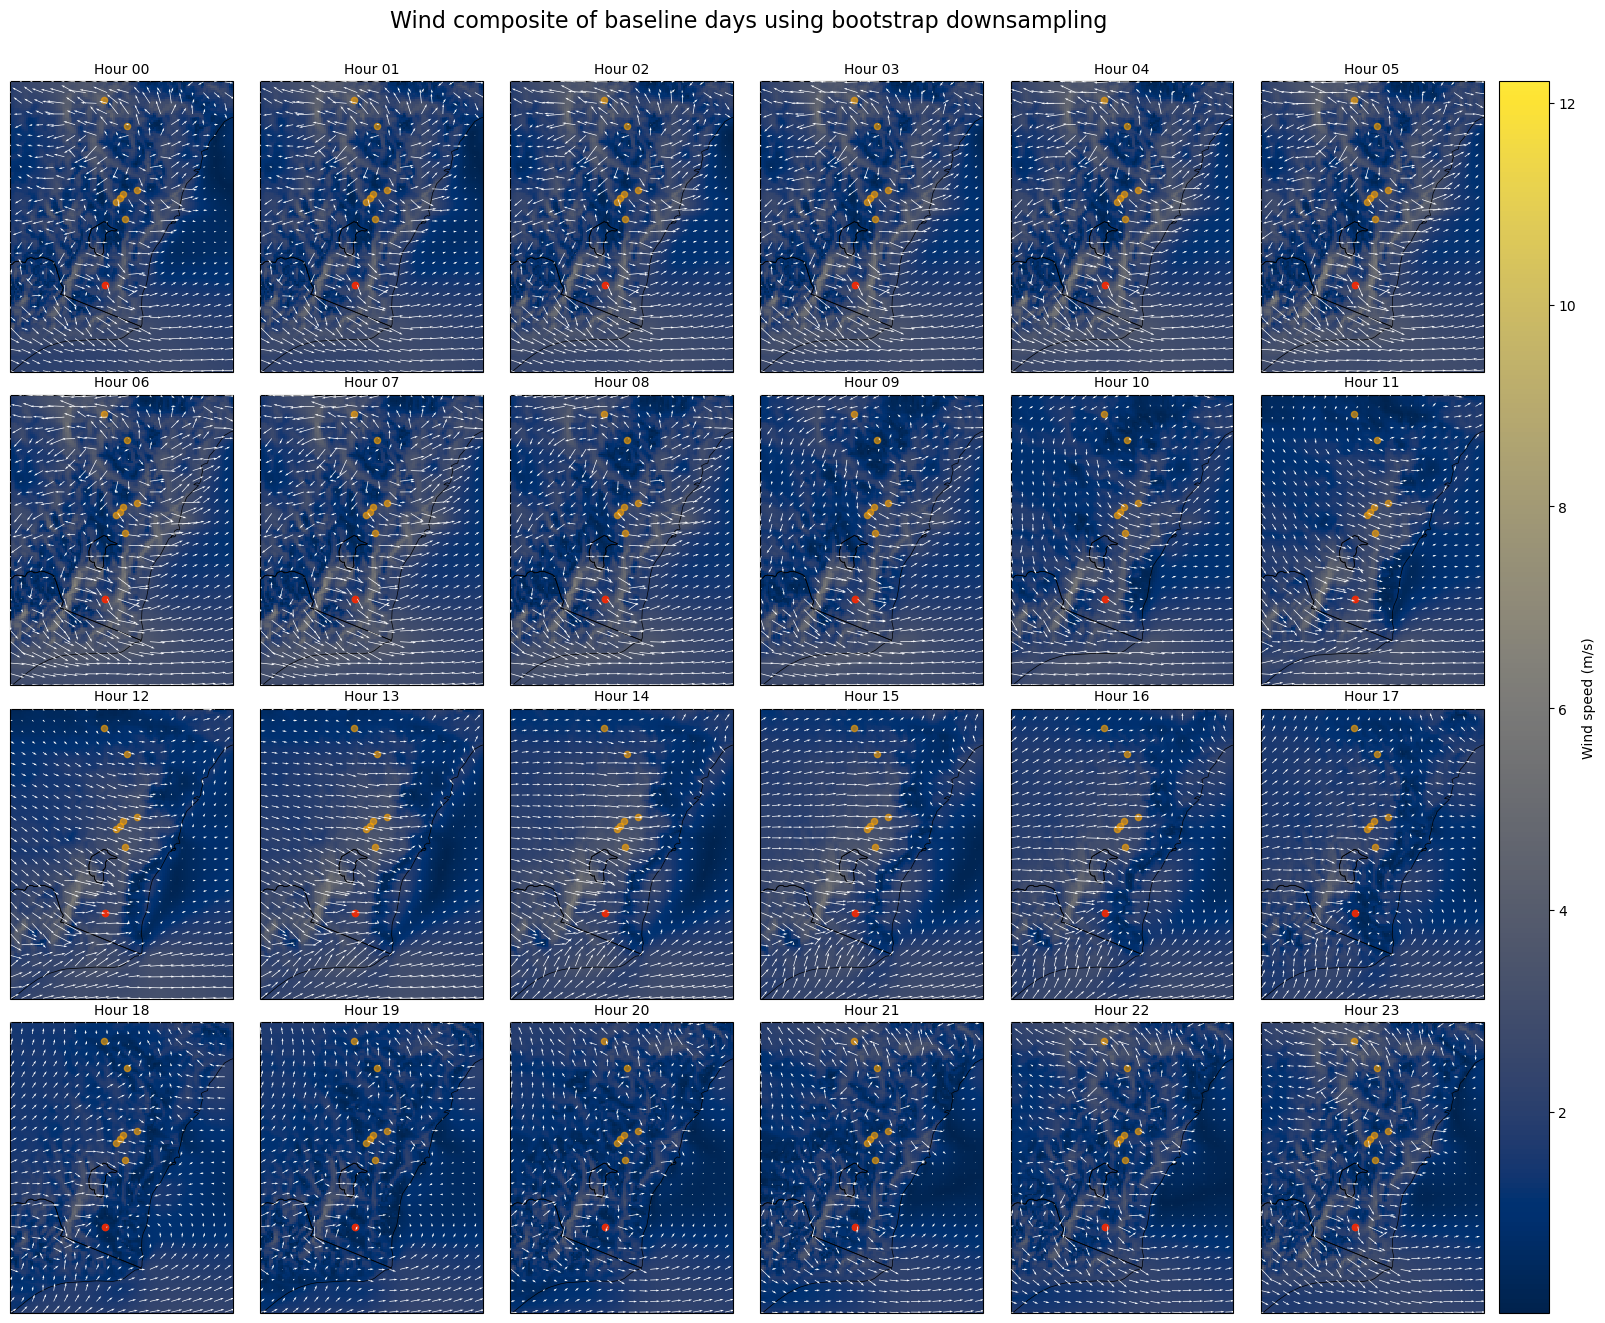

In [14]:
# Wind field plotting

vmax = max(ds['hw_speed_mean'].max(),ds['bl_speed_mean'].max())
vmin = min(ds['hw_speed_mean'].min(),ds['bl_speed_mean'].min())

for hr in range(23):    
    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=ds['hw_speed_mean'], hour=hr,
        u=ds['hw_u_mean'], v=ds['hw_v_mean'],
        cmap='cividis', vmax=vmax, vmin=vmin,
        colorbar_label='Wind speed (m/s)',
        title_prefix='Wind field on heatwave days at '
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/bootstrap_C2/vectors/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=ds['bl_speed_mean'], hour=hr,
        u=ds['bl_u_mean'], v=ds['bl_v_mean'],
        cmap='cividis', vmax=vmax, vmin=vmin,
        colorbar_label='Wind speed (m/s)',
        title_prefix='Wind field on baseline days at '
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/bootstrap_C2/vectors/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=ds['hw_speed_mean'].values,
    u=ds['hw_u_mean'].values,
    v=ds['hw_v_mean'].values,
    hours=None,
    ncols=6,
    vmin=vmin,
    vmax=vmax,
    figsize=(20, 16),
    cmap='cividis',
    colorbar_label='Wind speed (m/s)',
    title="Wind composite of heatwave days using bootstrap downsampling"
    )
fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/hw_bootstrap_div.png")
plt.close(fig)

fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=ds['bl_speed_mean'].values,
    u=ds['bl_u_mean'].values,
    v=ds['bl_v_mean'].values,
    hours=None,
    ncols=6,
    vmin=min(hw_min,bl_min),
    vmax=max(hw_max,bl_max),
    figsize=(20, 16),
    cmap='cividis',
    colorbar_label='Wind speed (m/s)',
    title = "Wind composite of baseline days using bootstrap downsampling"
    )
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bl_bootstrap_faceted.png")
plt.show(fig)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


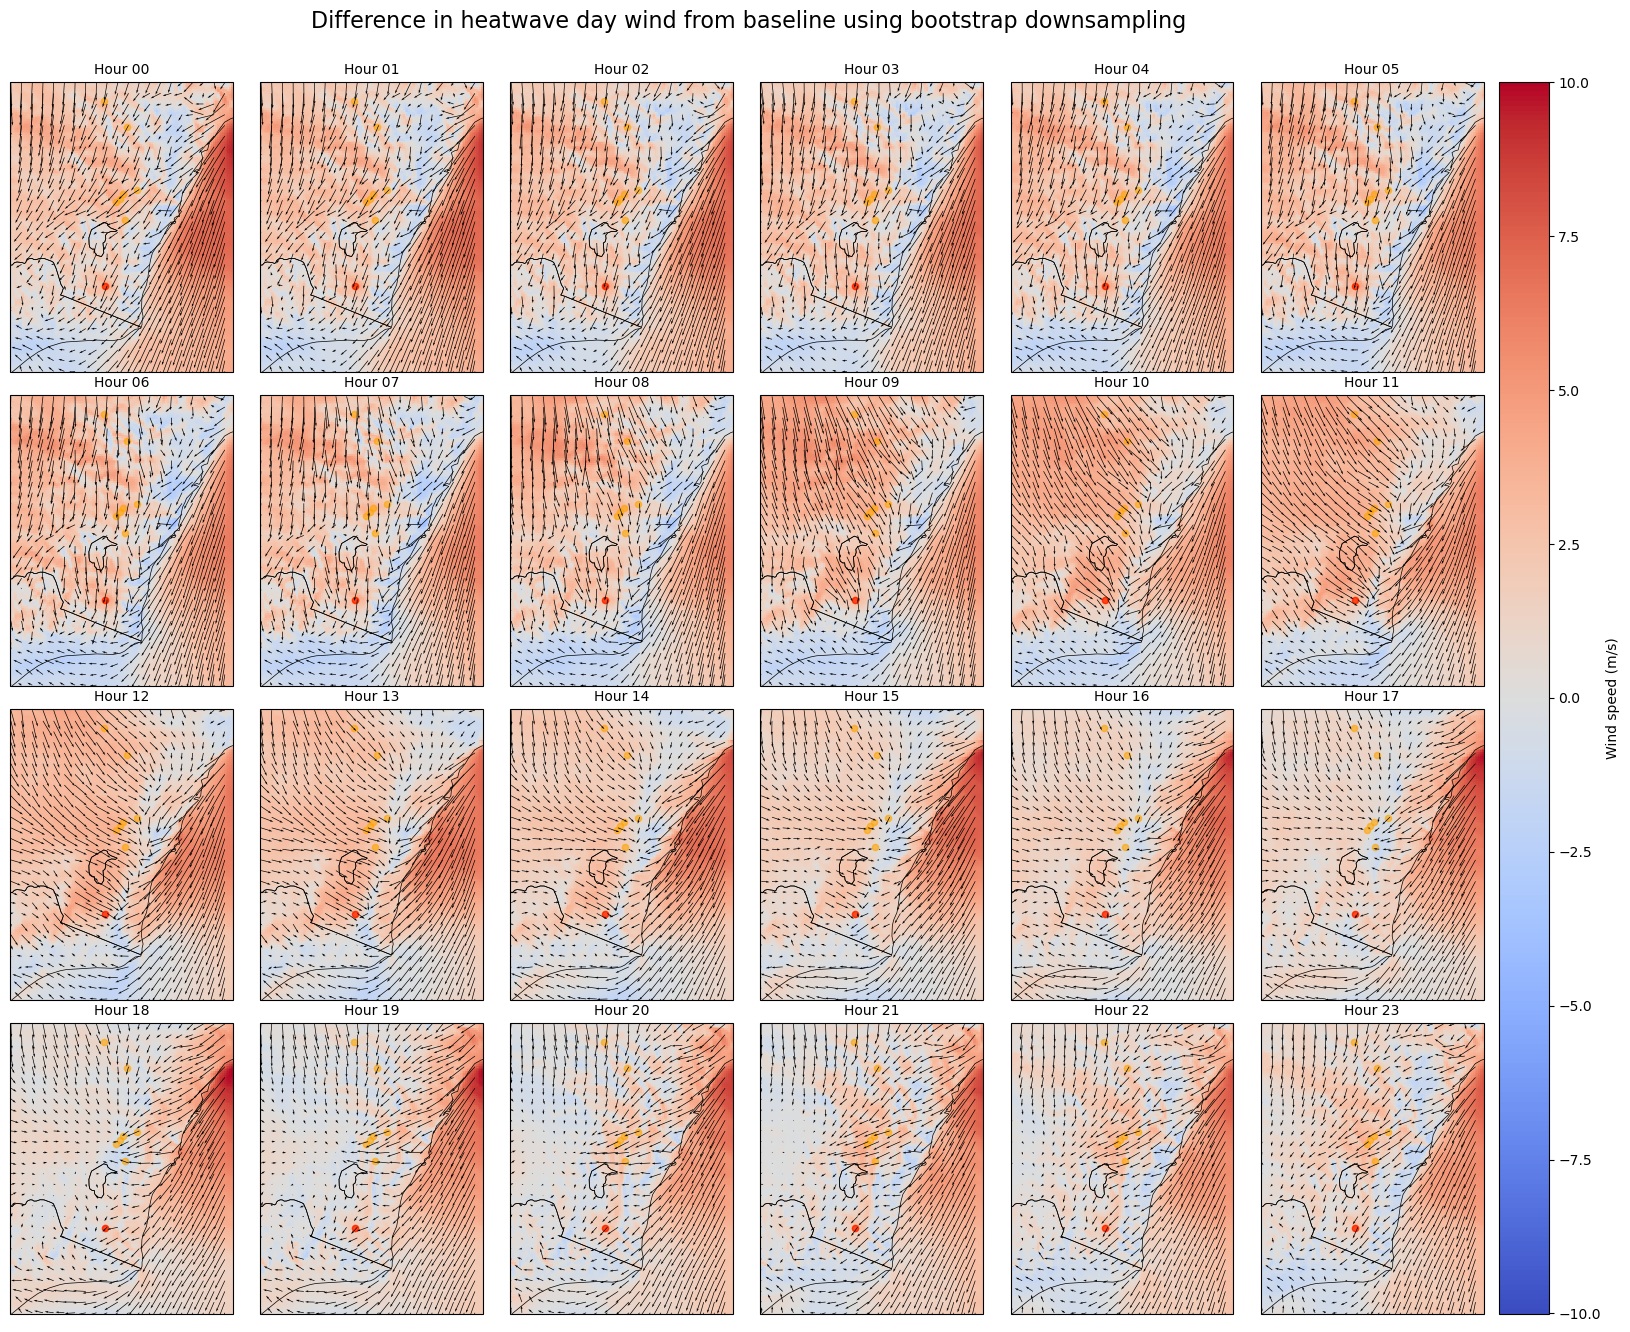

In [15]:
fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=ds['diff_speed_signed'].values,
    u=ds['diff_u_mean'].values,
    v=ds['diff_v_mean'].values,
    stipple=ds['diff_sig_joint_005'],
    hours=None,
    ncols=6,
    center_diff=True,
    figsize=(20, 16),
    cmap='coolwarm',
    quiver_color='black',
    colorbar_label='Wind speed (m/s)',
    title = "Difference in heatwave day wind from baseline using bootstrap downsampling"
    )
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/bootstrap_diff_faceted.png")

In [16]:
liberal_joint_pval = xr.ufuncs.minimum(ds['diff_u_pval'], ds['diff_v_pval'])
liberal_joint_pval.min()

<xarray.DataArray ()> Size: 8B
array(0.44)
Coordinates:
    height   float64 8B 100.0
    crs      int32 4B 0

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


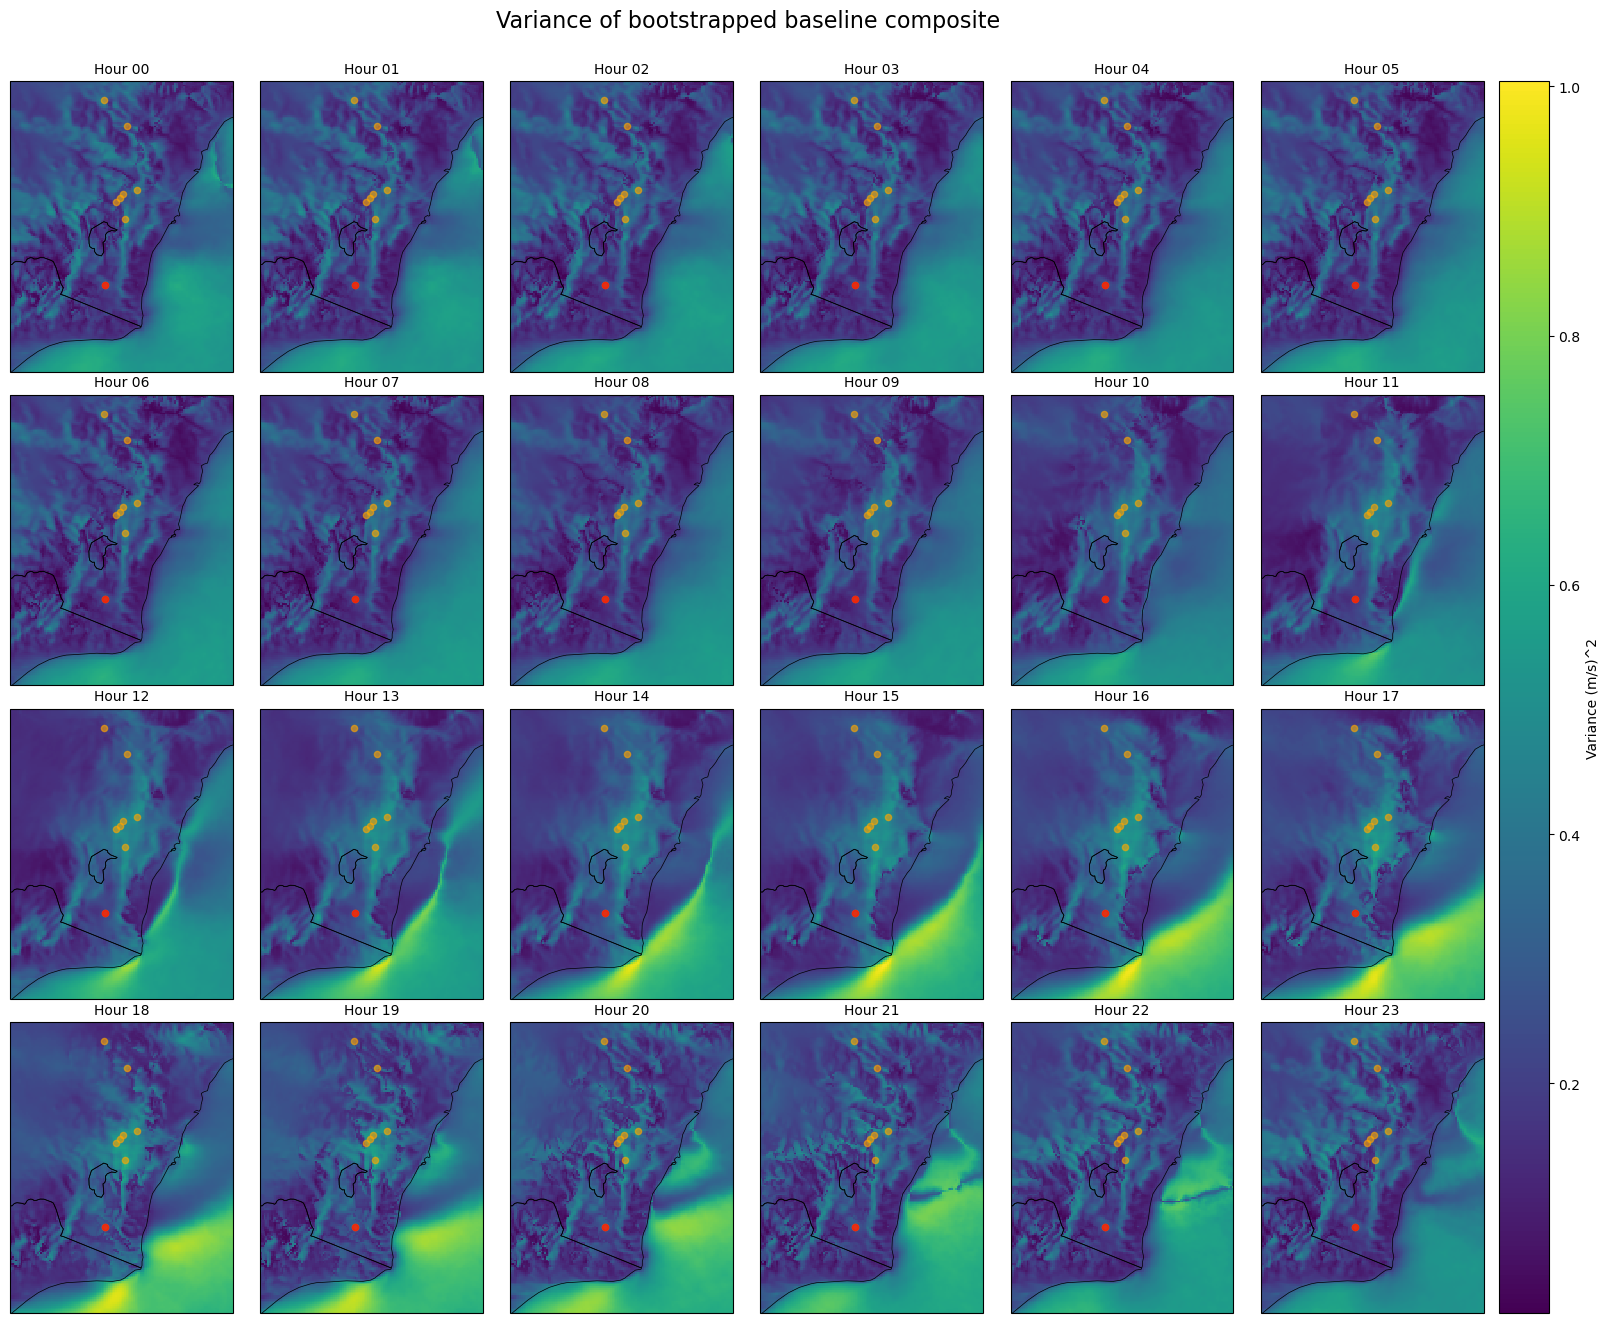

In [17]:
bl_var = ds['bl_speed_std']**2

fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=bl_var.values,
    hours=None,
    ncols=6,
    figsize=(20, 16),
    cmap='viridis',
    colorbar_label='Variance (m/s)^2',
    title = "Variance of bootstrapped baseline composite"
    )
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bootstrap_var_bl.png")
plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


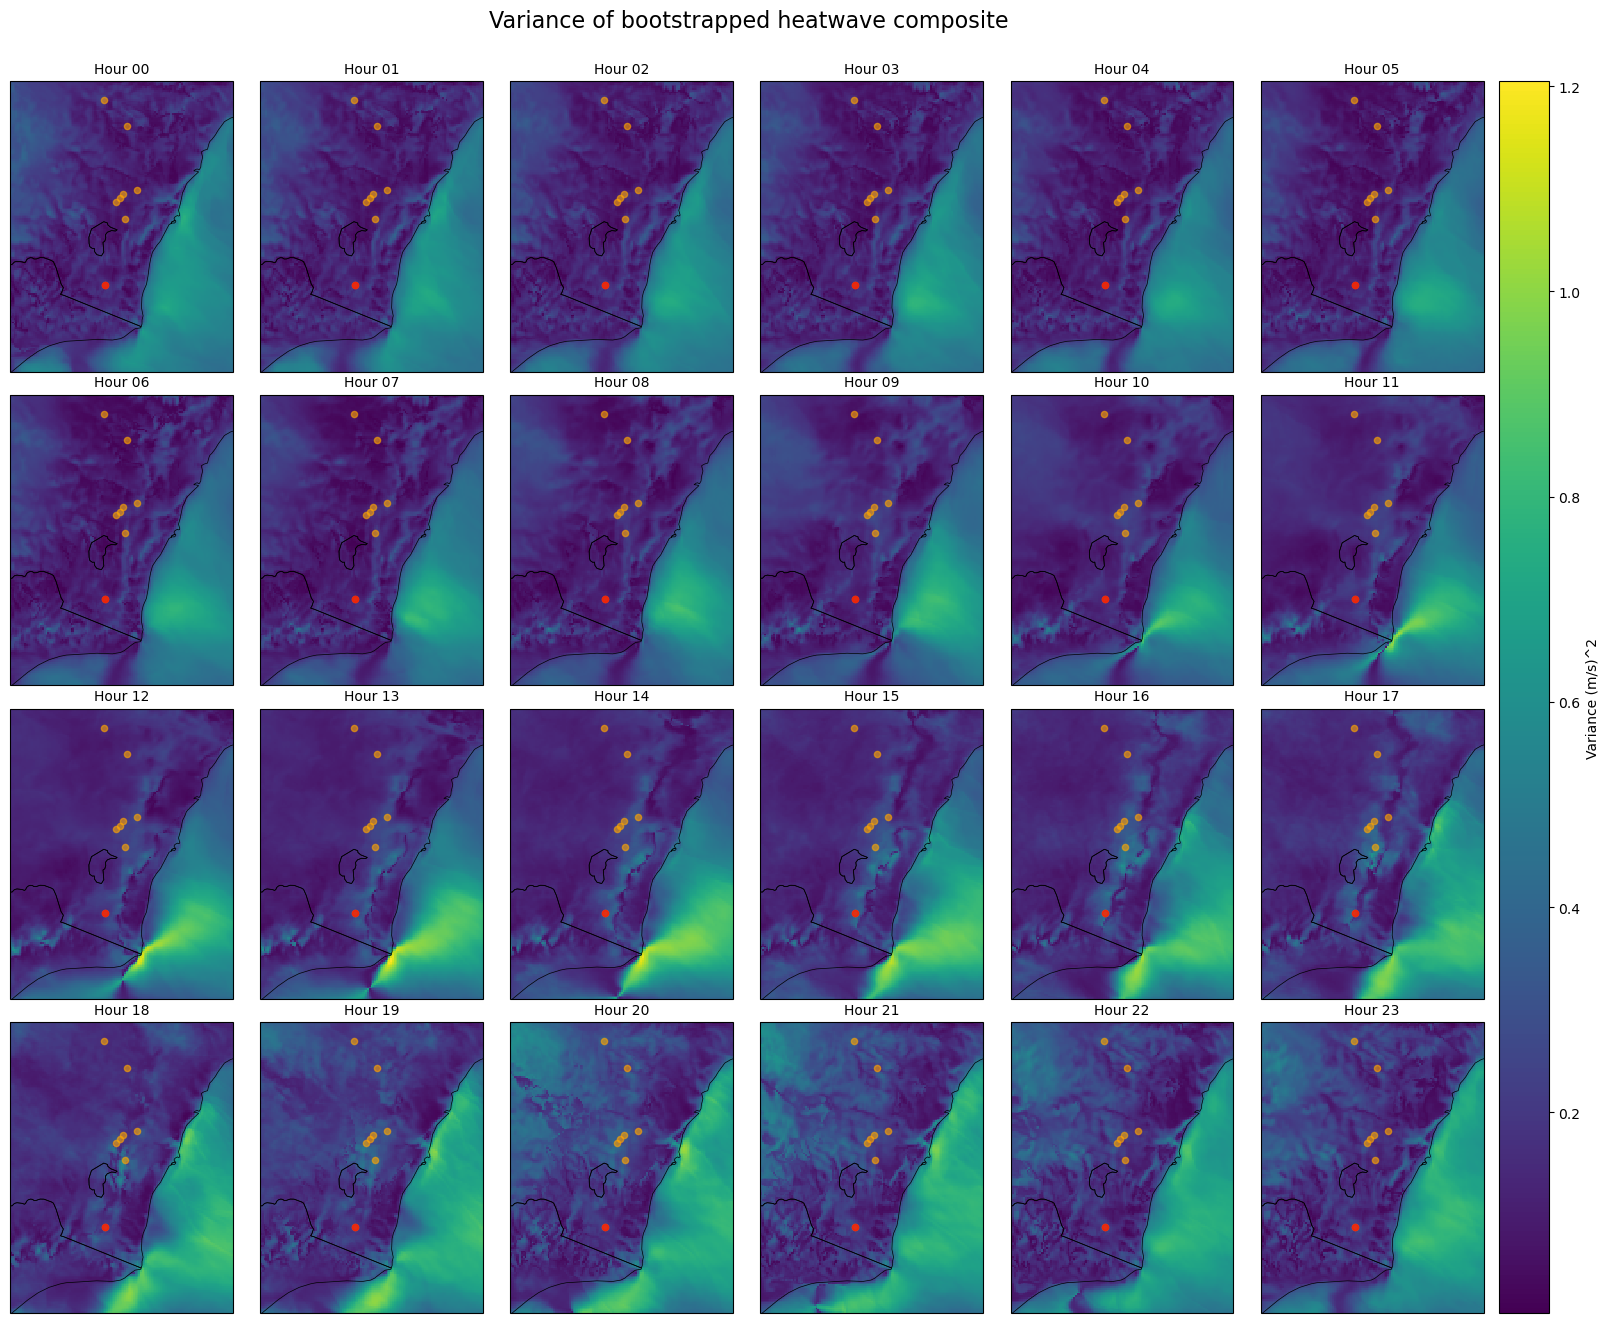

In [18]:
hw_var = ds['hw_speed_std']**2

fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=hw_var.values,
    hours=None,
    ncols=6,
    figsize=(20, 16),
    cmap='viridis',
    colorbar_label='Variance (m/s)^2',
    title = "Variance of bootstrapped heatwave composite"
    )
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/bootstrap_var_hw.png")
plt.show()